In [1]:
import os
import sys
import matplotlib.pyplot as plt
from functools import partial

print("Current directory:", os.getcwd())

sys.path.append('../../Diffusion_Model/')
sys.path.append('../analysis_scripts')
sys.path

Current directory: /Users/blandinegorce/Documents/StageLOCEAN/code/DINO-Fusion/Results/notebooks


['/Users/blandinegorce/.local/share/uv/python/cpython-3.12.6-macos-aarch64-none/lib/python312.zip',
 '/Users/blandinegorce/.local/share/uv/python/cpython-3.12.6-macos-aarch64-none/lib/python3.12',
 '/Users/blandinegorce/.local/share/uv/python/cpython-3.12.6-macos-aarch64-none/lib/python3.12/lib-dynload',
 '',
 '/Users/blandinegorce/Documents/StageLOCEAN/code/.venv/lib/python3.12/site-packages',
 '../../Diffusion_Model/',
 '../analysis_scripts']

In [2]:

import torch 
from pipelines.pipeline_tensor import DDPMPipeline_Tensor
import numpy as np
import torch
from utils import *
from pathlib import Path
import time
from ipdb import set_trace
from configs.base_config import *
from data_analytics import get_transformed_data, split
from metrics import compute_density

In [3]:
model_path = '../../../test-generate-img'
device = 'mps'

pipeline = DDPMPipeline_Tensor.from_pretrained(model_path).to(device)
noise_scheduler = pipeline.scheduler

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
# Load config
config = TrainingConfig()
print("Config loaded")

# Load data
train_dataloader = get_dataloader('../../../DATA_DinoFusion/'+config.data_file, batch_size=config.train_batch_size, fields=config.fields, normalisation='3-std')
print("Data loaded")

idt = iter(train_dataloader)
batch = next(idt)

#Compute noisy states
noisy_states = []

noises = torch.randn(batch.shape, device=batch.device)
bs = batch.shape[0]

timesteps = torch.tensor([0, 50, 100, 200, 300, 500, 750, 999], device=batch.device, dtype=torch.int64)

for t in timesteps:
    noisy_batch = noise_scheduler.add_noise(batch, noises, t.expand((bs)))
    noisy_states.append(noisy_batch)

Config loaded
Reading infos in ../../../DATA_DinoFusion/dino_1_4_degree_coarse_240125.tar
Data loaded


/Users/blandinegorce/Documents/StageLOCEAN/code/.venv/lib/python3.12/site-packages/webdataset/compat.py:389: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn(


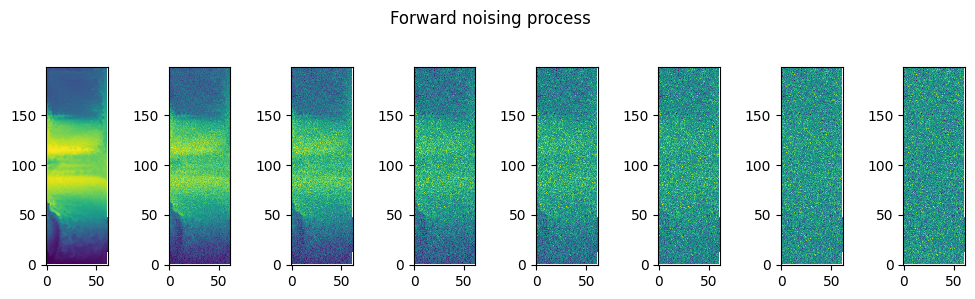

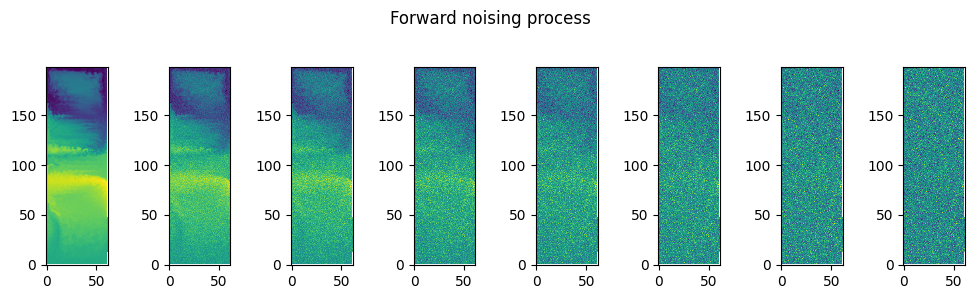

In [5]:
noisy_dict = {}
timesteps_str = [0, 50, 100, 200, 300, 500, 750, 999]

# Re-normalisation : bring back the data to it's initial scal
for i in range(len(noisy_states)):
    extractor = train_dataloader.get_transform().uncall
    noisy_samples = get_transformed_data(noisy_states[i], function=extractor)

    noisy_dict[timesteps_str[i]]= noisy_samples


#store sous forme de dict
idx = 1

def visualize_noisy_steps(noisy_dict, index=1, field='toce.npy', z=10, bs=8):
    fig, ax = plt.subplots(1, timesteps.shape[0], figsize=(10,3))

    for j in range(len(timesteps_str)):
        ax[j].imshow(noisy_dict[timesteps_str[j]][field][index,z,:,:])
    fig.suptitle('Forward noising process')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

visualize_noisy_steps(noisy_dict, index=idx)
visualize_noisy_steps(noisy_dict, index=idx, field='soce.npy')

In [19]:
def constraint_validation(dictionary, constraint='mean_density',sample_nb=1):
    mean_density = torch.tensor(np.loadtxt('../analysis_scripts/mean_density_train.txt'), device='cpu', dtype=torch.float32)

    if constraint=='salinity': 
        salinity = dictionary['soce.npy']
        constraint = torch.nansum((torch.nanmean(salinity, dim=[-1,-2]))**2, dim=-1)
        return torch.mean(constraint)
    
    elif constraint=='temperature': 
        temperature = dictionary['toce.npy'][sample_nb]
        return torch.nansum((torch.nanmean(temperature, dim=[-1,-2]))**2)
    
    elif constraint=='mean_density': 
        density = dictionary['density'][sample_nb]
        return torch.nansum((mean_density - torch.nanmean(density, dim=[-1,-2]))**2)

    elif constraint=='mean_density_gradient': 
        grad_density = dictionary['density'][sample_nb,:-1,:,:]-dictionary['density'][sample_nb,1:,:,:]
        grad_density[-1] = torch.zeros_like(grad_density[-1])
        grad_mean = mean_density[:-1]-mean_density[1:]
        grad_mean[-1] = torch.tensor([0])
        print(( grad_mean - torch.nanmean(grad_density, dim=[-1,-2]))**2)
        return torch.nansum(( grad_mean - torch.nanmean(grad_density, dim=[-1,-2]))**2)

    elif constraint=='density_gradient': 
        grad_density = dictionary['density'][sample_nb,:-1,:,:]-dictionary['density'][sample_nb,1:,:,:]
        grad_density[-1] = torch.zeros_like(grad_density[-1])
        return torch.nansum(torch.nn.functional.relu((grad_density>0).float()))

    else: 
        raise ValueError(f"Unknown constraint: {constraint}. Available constraints: mean_density, mean_density_gradient, density_gradient")



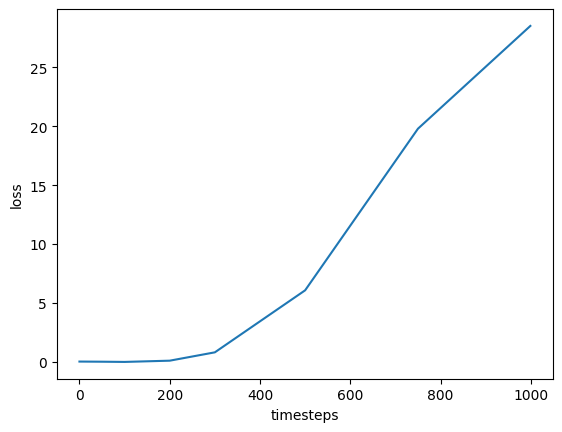

In [21]:
import xarray as xr
#Verify constraint satisfaction over a batch
n = len(timesteps_str)
file_mask_LR = xr.open_dataset("../analysis_scripts/data/DINO_1deg_mesh_mask_david_renamed.nc").sel(time_counter=0)
mask = file_mask_LR.rename({"nav_lev":"depth","y":"nav_lat","x":"nav_lon"})

constraint_satisfaction = []

for t in timesteps_str:
    sample_nb = 0 
    density = compute_density(noisy_dict[t], mask)
    noisy_dict[t]['density'] = density

    valid = constraint_validation(noisy_dict[t], constraint='mean_density')
    constraint_satisfaction.append(valid)


plt.plot(timesteps, constraint_satisfaction)
plt.ylabel('loss')
plt.xlabel('timesteps')
plt.show()



In [17]:
#UNORMALIZE SAMPLES
noisy_dict_norm = {}

extractor = partial(split, transform=train_dataloader.get_transform())
for i in range(len(noisy_states)):
    noisy_samples_norm=get_transformed_data(noisy_states[i], function=extractor)
    noisy_dict_norm[timesteps_str[i]]= noisy_samples_norm


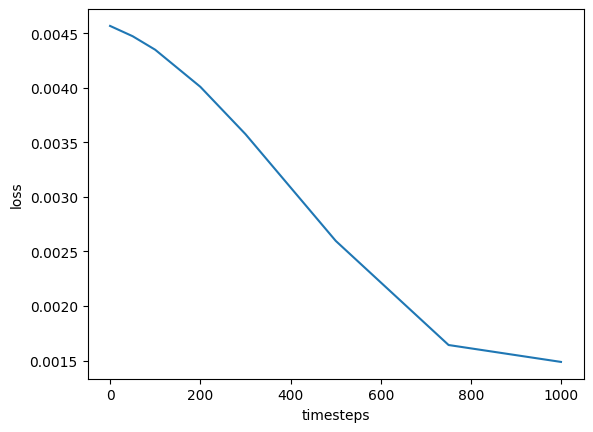

In [20]:
import xarray as xr
#Verify constraint satisfaction over a batch
n = len(timesteps_str)
constraint_satisfaction = []

for t in timesteps_str:
    valid = constraint_validation(noisy_dict_norm[t], constraint='salinity')
    constraint_satisfaction.append(valid)


plt.plot(timesteps, constraint_satisfaction)
plt.ylabel('loss')
plt.xlabel('timesteps')
plt.show()
